In [2]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
import matplotlib.pyplot as plt
import pandas as pd

/tmp/ipykernel_1460832/2328945532.py:3: VisibleDeprecationWarning: The yt.mods module is deprecated.
Deprecated since yt 4.1.0
This feature is planned for removal in yt 4.2.0
  from yt.mods import *


In [3]:
print(yt.__version__)

4.1.4


64 64 64
dx: 0.015625
t=0.00530606
Average Error: 6.449076942e-05
t/err=82.276
dx/err=242.28

12 12 12:
dx: 0.08333333333
t=0.150927966
Average Error: 0.05172071552
t/err=2.91
dx/err = 1.611

In [4]:
file1 = "../Output/plt00000/"
file2 = "../Output/plt02100/"

ds1 = AMReXDataset(file1, units_override = {"length_unit" : (100. , "l_pl")})
ds2 = AMReXDataset(file2, units_override = {"length_unit" : (100. , "l_pl")})

yt : [WARNING  ] 2024-12-08 12:16:38,558 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2024-12-08 12:16:38,559 Overriding length_unit: 100.0 l_pl.
yt : [INFO     ] 2024-12-08 12:16:38,608 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-08 12:16:38,608 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-08 12:16:38,609 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 12:16:38,609 Parameters: domain_right_edge         = [1. 1. 1.]


yt : [WARNING  ] 2024-12-08 12:16:38,720 Overriding code units: Use this option only if you know that the dataset doesn't define the units correctly or at all.
yt : [INFO     ] 2024-12-08 12:16:38,720 Overriding length_unit: 100.0 l_pl.
yt : [INFO     ] 2024-12-08 12:16:38,755 Parameters: current_time              = 11.142728739036
yt : [INFO     ] 2024-12-08 12:16:38,755 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2024-12-08 12:16:38,756 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 12:16:38,756 Parameters: domain_right_edge         = [1. 1. 1.]



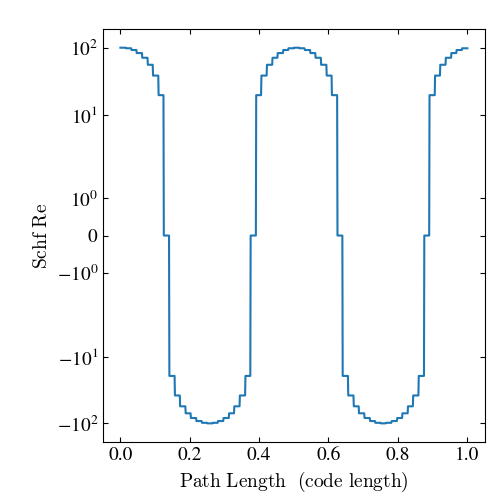


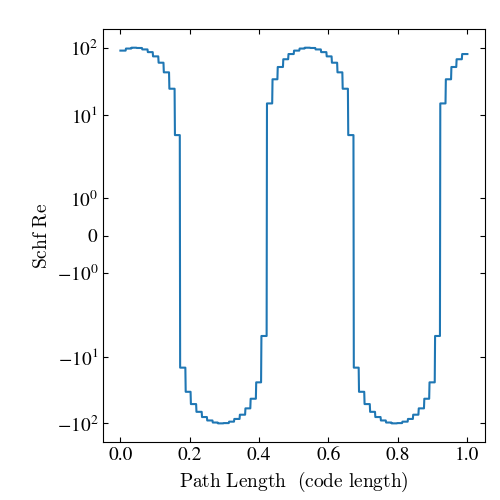

In [5]:
# Create a line plot of the 'SCHf_Re' variable over the x-axis
line_plot1 = yt.LinePlot(ds1, [('boxlib', 'SCHf_Re')], (0.0, 0.0, 0.0), (1.0, 0.0, 0.0), 1000)
line_plot2 = yt.LinePlot(ds2, [('boxlib', 'SCHf_Re')], (0.0, 0.0, 0.0), (1.0, 0.0, 0.0), 1000)
line_plot1.show()
line_plot2.show()

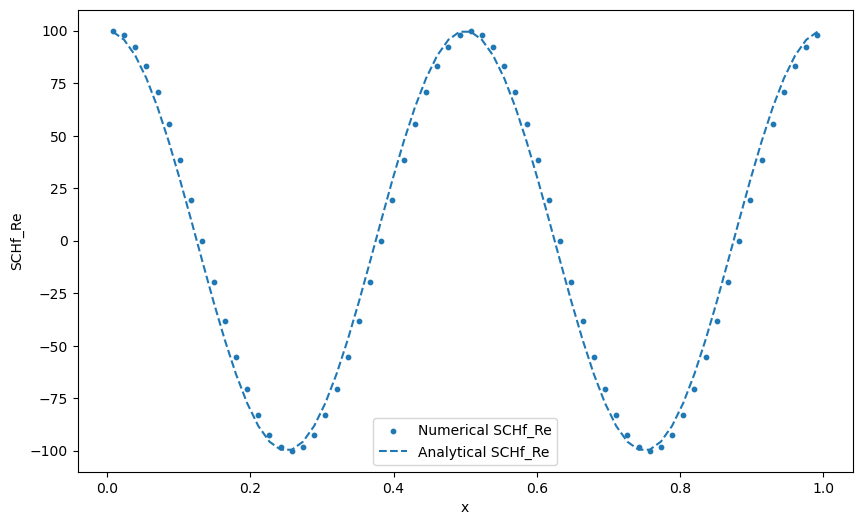

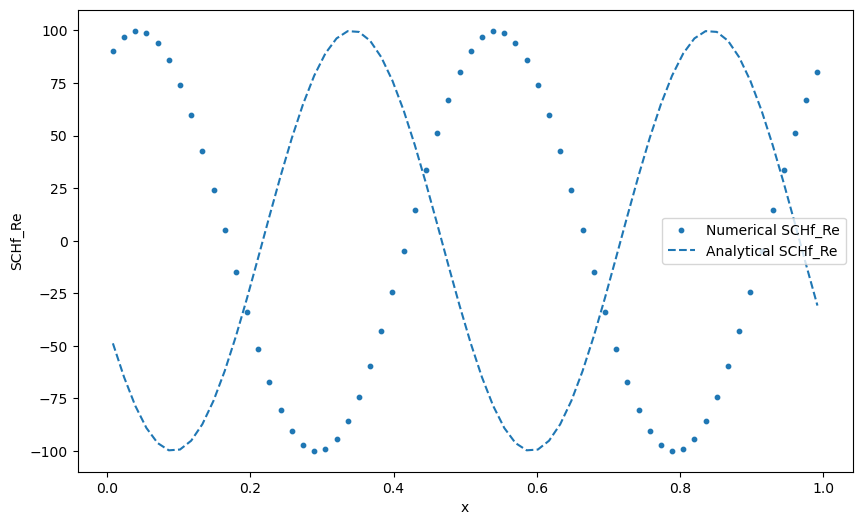

In [6]:
def extract_x_axis_arrays(AMReXDataset):
    ax = 0  # take a line cut along the x axis
    ray = AMReXDataset.ortho_ray(ax, (0.5, 0.5))  # taking a cut through the center of the y and z axes

    # Sort the ray values by 'x' so there are no discontinuities in the line plot
    srt = np.argsort(ray["index", "x"])
    return ray, srt


def compare_numerical_analytical_Re(AMReXDataset):
    ray, srt = extract_x_axis_arrays(AMReXDataset)

# Numerical solution
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(ray["index", "x"][srt]), np.array(ray['boxlib', 'SCHf_Re'][srt]), s=10, label='Numerical SCHf_Re')

# Analytical solution
    Lbox = AMReXDataset.domain_width[0].v  # Box length
    SCH_k_mode = 2  # Adjust as needed
    SCH_k = SCH_k_mode * 2.0 * np.pi / Lbox
    hbaroverm = 0.01917152  # Adjust as needed
    omega = SCH_k * SCH_k * hbaroverm / 2.0  # Dispersion relation
    SCH0 = 100.0  # Adjust as needed
    time = AMReXDataset.current_time.value  # Adjust as needed

    x = np.array(ray["index", "x"][srt])
    analytic_re = SCH0 * np.cos(SCH_k * x - omega * time)

    plt.plot(x, analytic_re, label='Analytical SCHf_Re', linestyle='--')

    plt.ylabel("SCHf_Re")
    plt.xlabel("x")
    plt.legend()
    plt.show()

AMReXDataset = ds1
compare_numerical_analytical_Re(AMReXDataset)
AMReXDataset = ds2
compare_numerical_analytical_Re(AMReXDataset)


In [10]:
ds = []
for data in dsLoad:
    ds.append(data)

TypeError: 'AMReXDataset' object is not callable

MovieWriter imagemagick unavailable; using Pillow instead.


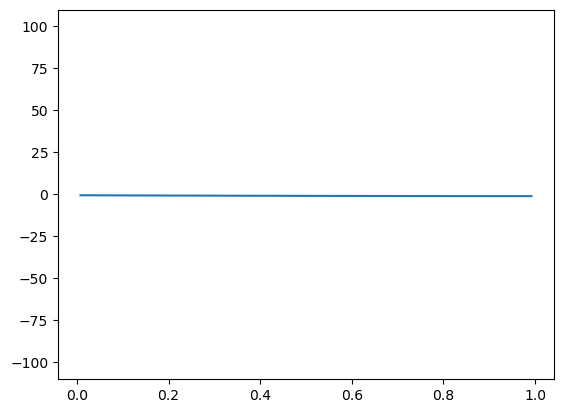

In [ ]:
import matplotlib.animation as animation

def create_animation(AMReXDataset, filename='animation.gif'):
    # Extract x-axis arrays
    ray, srt = extract_x_axis_arrays(AMReXDataset)
    x = np.array(ray["index", "x"][srt])
    y = np.array(ray['boxlib', 'SCHf_Re'][srt])

    # Create a figure and axis
    fig, ax = plt.subplots()

    # Create a line object, initially empty
    line, = ax.plot(x, y)

    # Function to update the y data
    def update(frame):
        line.set_ydata(np.sin(x + frame / 10.0))  # Update the data
        return line,

    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=100, blit=True)

    # Save the animation
    ani.save(filename, writer='imagemagick')

# Example usage
create_animation(ds1)



In [ ]:
data = ds1 

# Constants
Lbox = data.domain_width[0].v  # Box length
print(f"Lbox: {Lbox}")
SCH_k0 = 2  # Adjust as needed
SCH_k = SCH_k0 * 2.0 * np.pi / Lbox
hbaroverm = 0.01917152  # Adjust as needed
omega = SCH_k * SCH_k * hbaroverm / 2.0  # Dispersion relation
SCH0 = 100.0  # Adjust as needed
time = data.current_time.value  # Adjust as needed

# Get the data
ad = data.all_data()
x = ad['x'].value
numerical_re = ad[('boxlib', 'SCHf_Re')]
numerical_im = ad[('boxlib', 'SCHf_Im')]

# Compute analytical solution
analytic_re = SCH0 * np.cos(SCH_k * x - omega * time)
analytic_im = SCH0 * np.sin(SCH_k * x - omega * time)

# Compute errors
error_re = np.abs(numerical_re - analytic_re)
error_im = np.abs(numerical_im - analytic_im)
cell_error = np.sqrt(error_re**2 + error_im**2)

# Compute total errors
total_error_real = np.sum(error_re)
total_error_imag = np.sum(error_im)
total_error = np.sum(cell_error)
grid_count = data.domain_dimensions[0] * data.domain_dimensions[1] * data.domain_dimensions[2]

# Print results
print(f"Average Real Error: {total_error_real / grid_count}")
print(f"Average Imag Error: {total_error_imag / grid_count}")
print(f"Average Error: {total_error / grid_count}")

# Print specific grid point data (adjust target_i, target_j, target_k as needed)
target_i = 0
target_j = 0
target_k = 0
print(f"dx: {data.domain_width[0].v / data.domain_dimensions[0]}, dt: {data.current_time}")
print(f"i: {target_i}, j: {target_j}, k: {target_k}, t={time}, x={x[target_i]}")
print(f"Numerical Real: {numerical_re[target_i]}, Analytical Real: {analytic_re[target_i]}")
print(f"Numerical Imag: {numerical_im[target_i]}, Analytical Imag: {analytic_im[target_i]}")

Lbox: 1.0
Average Real Error: 99.99999999999997 dimensionless
Average Imag Error: 63.45731492255539 dimensionless
Average Error: 127.22167265616991 dimensionless
dx: 0.015625, dt: 0.0 code_time
i: 0, j: 0, k: 0, t=0.0, x=9.217552113317487e-32
Numerical Real: 70.71067811865477 dimensionless, Analytical Real: 100.0
Numerical Imag: 70.71067811865474 dimensionless, Analytical Imag: 1.1583117601311716e-28


In [ ]:
print(numerical_re.shape)
print(numerical_re)
print(analytic_re.shape)

print(str(data.domain_dimensions) + " results in shape of: " + str(data.domain_dimensions[0]**3))

"""seems like numerical_re is a 1D array of the grid points, so we need to reshape it to 3D"""

numerical_re = numerical_re.reshape(data.domain_dimensions)
print(numerical_re.shape)   

print(numerical_re[1].shape)
print(numerical_re[1][1].shape)

print(numerical_re)

In [ ]:
x_coords = x.reshape(data.domain_dimensions)

plt.figure(figsize=(10, 6))
plt.plot(x_coords[1][1], numerical_re[1][1], label='Numerical Real')
#plt.plot(x, analytic_re, label='Analytical Real', linestyle='--')
plt.xlabel('x')
plt.ylabel('Value')
plt.title('Numerical vs Analytical Real Part')
plt.legend()
plt.show()

In [ ]:
# get header from first row:
header = pd.read_fwf("../Output/runlog", header=None, nrows=1)
# remove first header
header = header.drop(header.columns[0], axis=1)
print(header)
# get data from second row onwards:
data = pd.read_fwf("../Output/runlog", header=None, skiprows=1)
# remive first column & last column
data = data.drop(data.columns[0], axis=1)
data = data.drop(data.columns[-1], axis=1)
print(data)
#data = pd.read_fwf("../Output/runlog", header=None)

# ignore first column

#print(data)


In [ ]:
print(ds.field_list)
print(ds.max_level)
ad = ds.all_data()

print(ad['boxlib', 'SCHf_Re'])
print(ad['boxlib', 'SCHf_Re'].shape)
print(ad['boxlib', 'SCHf_Im'])
print(ad['boxlib', 'SCHf_Im'].shape)

print(ad['boxlib', 'SCHf_Re'].min())
print(ad['boxlib', 'SCHf_Re'].mean())
print(ad['boxlib', 'SCHf_Re'].max())

# lets plot the real part of the scalar field
plot = yt.SlicePlot(ds, "z", ('boxlib', 'SCHf_Re'), data_source=ad)
plot.set_log(('boxlib', 'SCHf_Re'), False)
plot.set_cmap(('boxlib', 'SCHf_Re'), 'RdBu_r')


plot.show()


""" yt.ProjectionPlot(ds, "z", ('boxlib', 'SCHf_Re')).show() """
""" yt.ProjectionPlot(ds, "y", ('boxlib', 'SCHf_Im')).show()
yt.ProjectionPlot(ds, "z", ('boxlib', 'SCHf_Im')).show() """


""" print(ds.domain_width.prod())

plot = yt.SlicePlot(ds, "x", ('boxlib', 'SCHf_Im'), data_source=ad)
plot.show() """

In [ ]:
#Lets print SCHf_Re values over the x-axis



In [ ]:
ds1.print_stats()

# Create a line plot of the variables 'u' and 'v' with 1000 sampling points evenly
# spaced between the coordinates (0, 0, 0) and (0, 1, 0)

""" plot = yt.LinePlot(
    ds, [('boxlib', 'SCHf_Re'),('boxlib', 'SCHf_Im')], (0.0, 0.0, 0.0), (0.0, 1.0, 0.0), 1000
)
 """
plot1 = yt.LinePlot(
    ds1, [('boxlib', 'SCHf_Re'),('boxlib', 'SCHf_Im')], (0.0, 0.0, 0.0), (0.0, 5.0, 0.0), 1000
)

plot2 = yt.LinePlot(
    ds2, [('boxlib', 'SCHf_Re'),('boxlib', 'SCHf_Im')], (0.0, 0.0, 0.0), (0.0, 5.0, 0.0), 1000
)
# Add a legend
plot1.annotate_legend(('boxlib', 'SCHf_Re'))
plot2.annotate_legend(('boxlib', 'SCHf_Re'))

# Save the line plot
plot1.show()
plot2.show()

In [ ]:
print(ds.field_list)


ad = ds.all_data()

print(ad["SCHf_Re"])
print(ad["SCHf_Re"].shape)
print(ad["SCHf_Re"].min(), ad["SCHf_Re"].max())
print(ad["SCHf_Re"].mean())


In [ ]:
avInit = ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
ad1 = ds1.all_data()
ad1.max_level=0
#avFin  = ds1.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
avFin  = ad1.quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
def _relField (field, data, name, av):
    return data[name]/av
def _relSqIn(field,data):
    return _relField(field, data, "Edens", avInit)
def _relSqFin(field,data):
    return _relField(field, data, "Edens", avFin)
#    return _relField(field, data, "Edens", avInit)
ds.add_field(("boxlib","EdensRel"), function=_relSqIn, sampling_type="local", units="dimensionless",force_override=True)
ds1.add_field(("boxlib","EdensRel"), function=_relSqFin, sampling_type="local", units="dimensionless", force_override=True)

In [ ]:
mi, ma = ds.all_data().quantities.extrema("KGfdens")
print(ma)
print(mi)
mi, ma = ds1.all_data().quantities.extrema("KGfdens")
print(ma)
print(mi)

In [ ]:
#%matplotlib widget
#slc = yt.ProjectionPlot(ds, "z", "AxDens")
#slc = yt.SlicePlot(ds, "z", "AxDenSq")
#slc = yt.SlicePlot(ds, "z", "axion_phase", center=[0.,0.,0.15])
#slc = yt.SlicePlot(ds, "z", "KGf", center = [2.5,2.5,0])
#slc = yt.SlicePlot(ds, "z", "KGfdens")#, center = [0,0,0])
slc = yt.SlicePlot(ds, "z", "EdensRel")#, width = (3000, "l_pl"))#, center = [0,0,0])
#slc = yt.SlicePlot(ds, "z", "KGfdens")
slc.set_cmap(field=("EdensRel"), cmap="cmyt.dusk")
#slc.set_axes_unit("l_pl")
slc.zoom(1)
#slc.set_log("Edens", False)
#slc.set_log("KGfdens", False)
#slc.set_log("EdensRel", False)
slc.annotate_grids()
#slc.show()

In [ ]:
#slc = yt.ProjectionPlot(ds, "z", "AxDens")
#slc = yt.SlicePlot(ds, "z", "AxDenSq")
#slc = yt.SlicePlot(ds, "z", "axion_phase", center=[0.,0.,0.15])
#slc = yt.SlicePlot(ds1, "z", "KGfdens", center = [2.5,2.5,0])
ad1 = ds1.all_data()
#ad1.max_level=1
slc = yt.SlicePlot(ds1, "z", "EdensRel")#, center = [0,0,0], data_source=ad1)
#slc = yt.SlicePlot(ds1, "z", "KGfdens")#, center = [0,0,0])
slc.set_cmap(field=("EdensRel"), cmap="cmyt.dusk")
slc.zoom(1)
#slc.set_log("EdensRel", False)
#slc.set_log("KGfdens", False)
#slc.annotate_contour(("boxlib", "EdensRel"))
slc.annotate_grids()
#slc.show()

In [ ]:
f3 = open(file1[:-9]+"runlog", "r")
steps3, a3, phi3, dphi3, ratio = [], [], [], [], []
f3.readline()
f3.readline()
#cnt = 0
for line in f3.readlines():
#    cnt = cnt + 1
#    if(cnt % 2 == 1):
#        continue
    fields = line.split()
    steps3.append( float(fields[0]))
    a3.append(     float(fields[3]))
    phi3.append(   float(fields[7])) # N.B. For new runlogs, phi and dphi are 7 and 8 resp., since I've added e-folds to the output.
    dphi3.append(  float(fields[8]))
    ratio.append(  float(fields[9]))
f3.close()

In [ ]:
#%matplotlib widget
plt.plot(steps3,ratio)
plt.xlabel("$steps$")
plt.ylabel("$H^2/(8 \\pi \\rho / 3)$")
plt.show()

In [ ]:
#%matplotlib widget
plt.plot(steps3,a3)
plt.xlabel("$steps$")
plt.ylabel("$a$")
#plt.semilogy()
plt.show()

In [ ]:
#%matplotlib widget
plt.plot(steps3,phi3)
plt.xlabel("$steps$")
plt.ylabel("<$\phi$>")
#plt.semilogy()
plt.show()

In [ ]:
# #sc = yt.create_scene(ds1, ("boxlib", "KGfdens"), lens_type="perspective", )
# #sc = yt.create_scene(ds, ("boxlib", "EdensRel"))#, lens_type="perspective", )
# #sc.annotate_domain(ds, color=[1, 1, 1, 0.01])
# #sc.annotate_grids(ds, alpha=0.0004)
# sc = yt.create_scene(ds1, ("boxlib", "EdensRel"))#, lens_type="perspective", )
# sc.annotate_domain(ds1, color=[1, 1, 1, 0.01])
# sc.annotate_grids(ds1, alpha=0.0004)
# source = sc[0]
# source.set_field(("boxlib", "EdensRel"))
# source.set_log(True)
# source.tfh.gray_opacity = False
# #source.tfh.set_bounds((1e-15, 1e-6))
# source.tfh.set_log(True)

# #mn, mx = ds.all_data().quantities.extrema("EdensRel")
# mn, mx = ds1.all_data().quantities.extrema("EdensRel")
# if mn < 0:
#     mn = -mn
# bounds = (mn, mx)

# # Since this rendering is done in log space, the transfer function needs
# # to be specified in log space.
# tf = yt.ColorTransferFunction(np.log10(bounds))

# tf.add_layers(5, colormap="arbre")

# source.tfh.tf = tf
# source.tfh.bounds = bounds

# sc.camera.zoom(0.9)
# sc.camera.set_resolution(1000)
# #source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
# sc.show(sigma_clip=0.9)

In [ ]:
# sc = yt.create_scene(ds1, ("boxlib", "EdensRel"), lens_type="plane-parallel", )
# source = sc[0]
# source.set_field(("boxlib", "EdensRel"))
# source.tfh.gray_opacity = True
# source.tfh.set_bounds((5, 20))
# source.tfh.set_log(False)
# sc.camera.zoom(0.8)
# #source.tfh.plot("transfer_function.png", profile_field=("boxlib", "KGf"))
# sc.show(sigma_clip=0.7)

In [ ]:
# sc.camera.zoom(3)
# sc.render()
# sc.show(sigma_clip=3)

In [ ]:
#ds1.field_list

In [ ]:
# Use this if you need to plot a subset of the layers in the data
#ad1 = ds1.all_data()
#ad1.max_level=0
#slc = yt.SlicePlot(ds1, "z", "EdensRel", center = [0,0,0], data_source=ad1)